In [67]:
import numpy as np
import scipy
from scipy.sparse.linalg import spsolve
from matplotlib import pyplot as plt

Outline for Simple Least Squares Phase Unwrapping

1) create a smooth function to represent the absalute phase (unwrapped phase) 
2) Apply the wrapping opperator to create the princible phase (wrapped phase) 
3) Demonstrate Itoh's condition
$$
\nabla \phi = W(\nabla \psi)
$$
4) create a sparse matrix to represent the gradient opperator
5) solve the least squares phase unwrapping problem by imposing Itoh's condition
$$
\argmin_\phi \| \nabla \phi - W(\nabla \psi) \|^2_2
$$
where $\phi$ is the absolute phase, $\psi$ is the princible phase, and $W$ is the wrapping opperator given by 
$$
W(y): R \rightarrow [- \pi, \pi) = [(y+\pi) \text{ mod } 2 \pi] - \pi
$$
6) Do error analysis on the final result

Note that we will have to descritize the gradient opperator $\nabla \rightarrow G$. This can be done according to
$$
G = 
\begin{pmatrix}
    I_{Ny} \otimes D_x \\
    D_y \otimes I_{Nx} \\
    0 \cdots 1 \cdots 0
\end{pmatrix}
$$

Where the $D_x$ and $D_y$ are first order, forard finite differnce opperators in the $x$ and $y$ direction respectively and the last row of $G$ ecnodes the condition $\phi_0 = \psi_0$ where is $\psi_0 \in [-\pi, \pi]$ is the values of the princible phase at some location where the wrapping opperator has no effect. This being the case, we also make the substitution $W(\nabla \psi) \rightarrow W(G \psi) $.




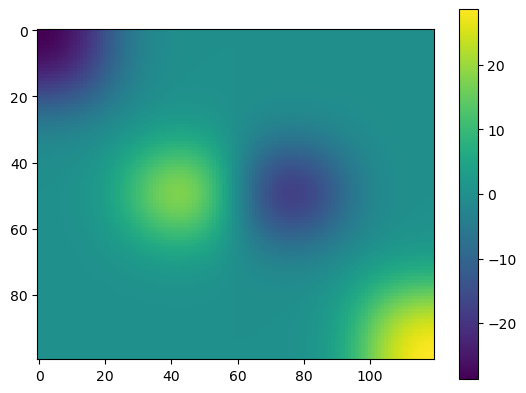

In [68]:

# create a smooth function to phase unwrapp

Nx = 120
Ny = 100

Phi = np.zeros((Ny, Nx), dtype=np.float32)
Phi[40:60, 30:60] = 10*np.pi
Phi[40:60, 60:90] = -10*np.pi
Phi[:20, :20] = -10*np.pi
Phi[-20:, -20:] = 10*np.pi
Phi = scipy.ndimage.gaussian_filter(Phi, sigma=10)

plt.imshow(Phi)
plt.colorbar()



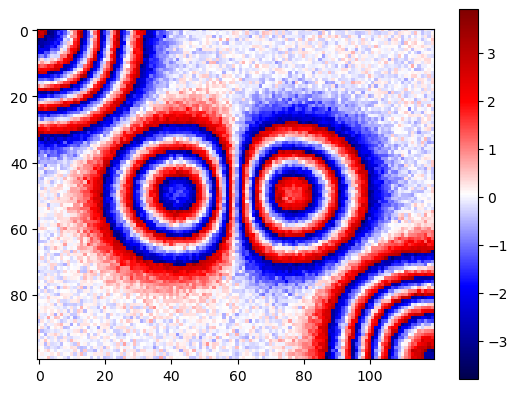

In [69]:
# wrap the absalute phase to compute the principle phase, and add some noise the princible phase

def wrap(y): 
	return ((y + np.pi) % (2*np.pi)) - np.pi

Psi = wrap(Phi)
Psi += 0.25*np.random.randn(Psi.shape[0], Psi.shape[1])
plt.imshow(Psi, cmap="seismic")
plt.colorbar()


([], [])

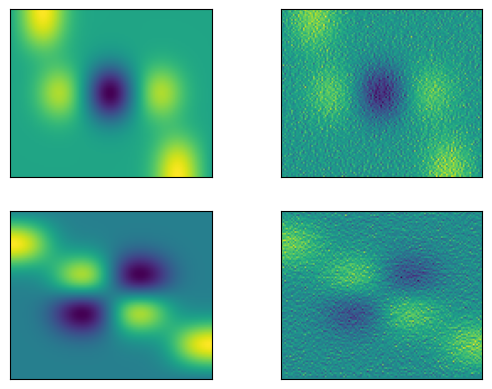

In [70]:
# Demonstate Ithoh's condition

dx_phi = 0.0*Phi
dx_phi[:,:-1] = np.diff(Phi, axis=1)
dy_phi = 0.0*Phi
dy_phi[:-1,:] = np.diff(Phi, axis=0)

dx_psi = 0.0*Psi
dx_psi[:,:-1] = wrap(np.diff(Psi, axis=1))
dy_psi = 0.0*Psi
dy_psi[:-1,:] = wrap(np.diff(Psi, axis=0))

plt.subplot(221)
plt.imshow(dx_phi)
plt.xticks([])
plt.yticks([])
plt.subplot(222)
plt.imshow(dx_psi)
plt.xticks([])
plt.yticks([])
plt.subplot(223)
plt.imshow(dy_phi)
plt.xticks([])
plt.yticks([])
plt.subplot(224)
plt.imshow(dy_psi)
plt.xticks([])
plt.yticks([])

In [71]:
Nm = Nx*Ny

Ix = scipy.sparse.identity(Nx, dtype=np.float32)
Iy = scipy.sparse.identity(Ny, dtype=np.float32)

ones_x = np.ones((Nx), dtype=np.float32)
ones_y = np.ones((Ny), dtype=np.float32)

diags_x = np.vstack((-ones_x, ones_x))
Dx = scipy.sparse.spdiags(diags_x, [0, 1], Nx-1, Nx, format="csr")
Gx = scipy.sparse.kron(Iy, Dx)

diags_y = np.vstack((-ones_y, ones_y))
Dy = scipy.sparse.spdiags(diags_y, [0, 1], Ny-1, Ny, format="csr")
Gy = scipy.sparse.kron(Dy, Ix)

# set dirichilet condition
bol_x_ind = Nx-1
bol_y_ind = 0
last_row_bol_ind = np.ravel_multi_index((bol_x_ind, bol_y_ind), (Nx, Ny))
last_row = scipy.sparse.csr_matrix(([1.0], ([0], [last_row_bol_ind])), shape=(1, Nm), dtype=np.float32)

G = scipy.sparse.bmat(
	[
		[Gx],
        [Gy],
		[last_row]
	], 
	format="csr")


In [72]:
# make data vector
d = wrap(G @ Psi.flatten())

# solve least squares unwrapping problem 
RHS = G.T@G
LHS = G.T@d
Phi_star = spsolve(RHS, LHS)



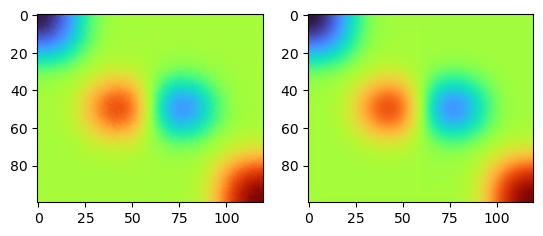

In [73]:
Phi_star = Phi_star.reshape(Phi.shape)

plt.subplot(121)
plt.imshow(Phi_star, cmap="turbo")
plt.subplot(122)
plt.imshow(Phi, cmap="turbo")
# plt.colorbar()

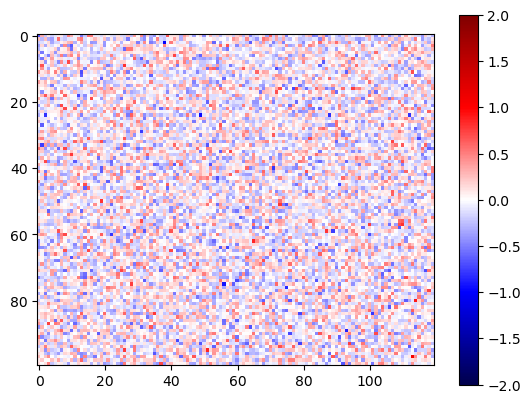

In [74]:
plt.imshow(Phi_star-Phi, cmap="seismic", vmin=-2.0, vmax=2.0)
plt.colorbar()

(array([2.000e+00, 6.100e+01, 4.200e+02, 1.544e+03, 3.283e+03, 3.731e+03,
        2.158e+03, 6.870e+02, 1.050e+02, 9.000e+00]),
 array([-1.06300735, -0.85733163, -0.65165597, -0.44598031, -0.24030459,
        -0.03462887,  0.17104673,  0.37672246,  0.58239818,  0.7880739 ,
         0.99374962]),
 <BarContainer object of 10 artists>)

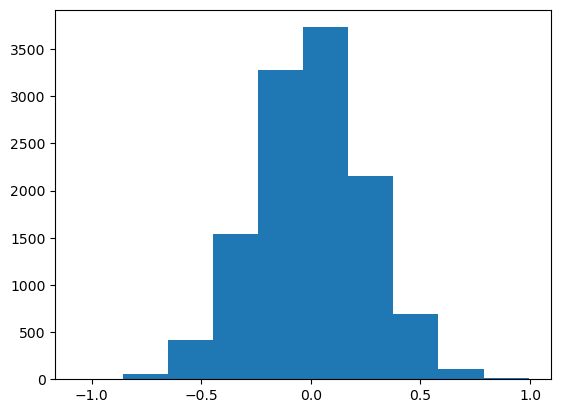

In [75]:
plt.hist((Phi-Phi_star).flatten())

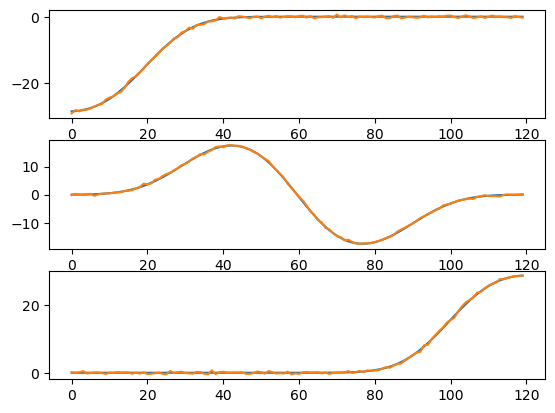

In [76]:
plt.subplot(311)
plt.plot(Phi[0,:])
plt.plot(Phi_star[0,:])
plt.subplot(312)
plt.plot(Phi[50,:])
plt.plot(Phi_star[50,:])
plt.subplot(313)
plt.plot(Phi[-1,:])
plt.plot(Phi_star[-1,:])